In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rand
import math

import statsmodels.api as sm
import statsmodels.formula.api as smf


1. Limpieza de datos: Tratar valores faltantes, codificaciones extrañas y posibles errores.

In [5]:
# Read in the dataset
df = pd.read_csv('./car_sales_data.csv')
print(df.head())

         Date      Salesperson   Customer Name Car Make  Car Model  Car Year  \
0  2022-08-01  Monica Moore MD     Mary Butler   Nissan     Altima      2018   
1  2023-03-15     Roberto Rose  Richard Pierce   Nissan      F-150      2016   
2  2023-04-29     Ashley Ramos    Sandra Moore     Ford      Civic      2016   
3  2022-09-04   Patrick Harris    Johnny Scott     Ford     Altima      2013   
4  2022-06-16       Eric Lopez   Vanessa Jones    Honda  Silverado      2022   

   Sale Price  Commission Rate  Commission Earned  
0       15983         0.070495            1126.73  
1       38474         0.134439            5172.40  
2       33340         0.114536            3818.63  
3       41937         0.092191            3866.20  
4       20256         0.113490            2298.85  


In [6]:
#Información general del dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500000 entries, 0 to 2499999
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Date               object 
 1   Salesperson        object 
 2   Customer Name      object 
 3   Car Make           object 
 4   Car Model          object 
 5   Car Year           int64  
 6   Sale Price         int64  
 7   Commission Rate    float64
 8   Commission Earned  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 171.7+ MB
None


In [6]:
#Revisar valores faltantes por columna
print(df.isnull().sum())

Date                 0
Salesperson          1
Customer Name        1
Car Make             1
Car Model            1
Car Year             1
Sale Price           1
Commission Rate      1
Commission Earned    1
dtype: int64


In [7]:
df = df.dropna(subset=["Car Make", "Car Model", "Sale Price", "Car Year"])

In [8]:
print(df.isnull().sum())

Date                 0
Salesperson          0
Customer Name        0
Car Make             0
Car Model            0
Car Year             0
Sale Price           0
Commission Rate      0
Commission Earned    0
dtype: int64


In [9]:
print(df["Car Make"].unique())
print(df["Sale Price"].unique())

['Nissan' 'Ford' 'Honda' 'Toyota' 'Chevrolet']
[15983. 38474. 33340. ... 14499. 18868. 19538.]


2. Descripción de las variables y datos: Identificar los tipos, calcular estadísticos para sa-
ber cómo se distribuyen, rangos, e identificar valores atípicos o también conocidos
como outliers.

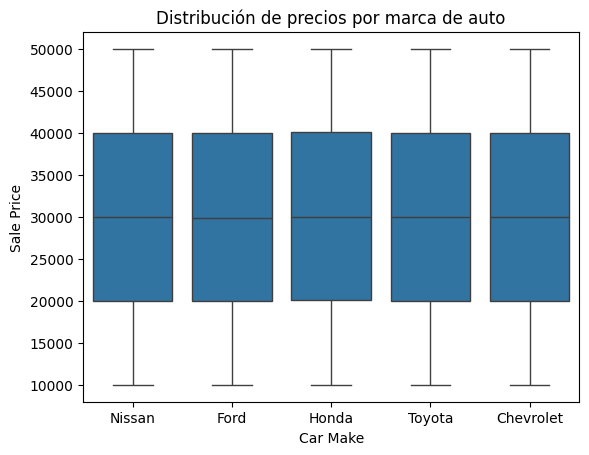

In [10]:
sns.boxplot(x="Car Make", y="Sale Price", data=df)
plt.title("Distribución de precios por marca de auto")
plt.show()

In [8]:
q_low = df["Sale Price"].quantile(0.01)
q_high = df["Sale Price"].quantile(0.99)
df = df[(df["Sale Price"] >= q_low) & (df["Sale Price"] <= q_high)]

In [12]:
print("Tamaño del dataset limpio:", df.shape)

Tamaño del dataset limpio: (1429836, 9)


In [13]:
print("\nEstadísticos descriptivos de variables numéricas:")
print(df[["Sale Price", "Commission Earned"]].describe())


Estadísticos descriptivos de variables numéricas:
         Sale Price  Commission Earned
count  1.429836e+06       1.429836e+06
mean   3.001319e+04       3.001232e+03
std    1.131107e+04       1.461961e+03
min    1.040300e+04       5.211700e+02
25%    2.022600e+04       1.840090e+03
50%    3.000300e+04       2.744140e+03
75%    3.982300e+04       3.966783e+03
max    4.959200e+04       7.437190e+03


In [14]:
print("\nFrecuencia de los modelos más comunes:")
print(df["Car Model"].value_counts().head(10))

print("\nFrecuencia de las marcas más comunes:")
print(df["Car Make"].value_counts())


Frecuencia de los modelos más comunes:
Car Model
Silverado    286731
Civic        286331
Corolla      285829
F-150        285514
Altima       285431
Name: count, dtype: int64

Frecuencia de las marcas más comunes:
Car Make
Honda        286335
Chevrolet    286260
Ford         286219
Toyota       285723
Nissan       285299
Name: count, dtype: int64


In [15]:
print("\nRango de precios:")
print("Mínimo:", df["Sale Price"].min())
print("Máximo:", df["Sale Price"].max())

print("\nRango de anios vendidos:")
print("Mínimo:", df["Car Year"].min())
print("Máximo:", df["Car Year"].max())


Rango de precios:
Mínimo: 10403.0
Máximo: 49592.0

Rango de anios vendidos:
Mínimo: 2010.0
Máximo: 2022.0


In [9]:
Q1 = df["Sale Price"].quantile(0.25)
Q3 = df["Sale Price"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Sale Price"] < Q1 - 1.5*IQR) | (df["Sale Price"] > Q3 + 1.5*IQR)]
print("\nCantidad de outliers en Precio:", outliers.shape[0])


Cantidad de outliers en Precio: 0


Descripcion de las variables y datos:
-Identifica cuales son numericas y cuales son categoricas
-Estadistico descriptivo para variables numericas
-Estadistico descriptivo para variables categoricas

In [17]:
print("Tipos de variables en el DataFrame:")
print(df.dtypes)

Tipos de variables en el DataFrame:
Date                  object
Salesperson           object
Customer Name         object
Car Make              object
Car Model             object
Car Year             float64
Sale Price           float64
Commission Rate      float64
Commission Earned    float64
dtype: object


3. Visualizaciones: Realizar gráficos que ayuden a comprender tendencias, relaciones,
diferencias, agrupamientos y otros comportamientos presentes en los datos.

In [10]:
#Estadisticos descriptivos, solo para variables numericas
pd.set_option("display.float_format", "{:,.2f}".format) #fuerza a mostrar los numeros con 2 decimales
print("\nEstadisticos descriptivos de variables numericas:")
print(df.describe())


Estadisticos descriptivos de variables numericas:
          Car Year   Sale Price  Commission Rate  Commission Earned
count 2,450,020.00 2,450,020.00     2,450,020.00       2,450,020.00
mean      2,016.00    30,012.41             0.10           3,000.96
std           3.74    11,314.23             0.03           1,461.95
min       2,010.00    10,402.00             0.05             521.17
25%       2,013.00    20,220.00             0.07           1,839.74
50%       2,016.00    30,006.00             0.10           2,743.84
75%       2,019.00    39,823.00             0.13           3,965.44
max       2,022.00    49,597.00             0.15           7,437.19


In [19]:
#Estadisticos descriptivos para variables categoricas
print("\nEstadisticos descriptivos de variables categoricas:")
print(df.describe(include=['object', 'category']))


Estadisticos descriptivos de variables categoricas:
              Date    Salesperson  Customer Name Car Make  Car Model
count      1429836        1429836        1429836  1429836    1429836
unique         366         397434         397650        5          5
top     2023-02-16  Michael Smith  Michael Smith    Honda  Silverado
freq          4083            733            674   286335     286731


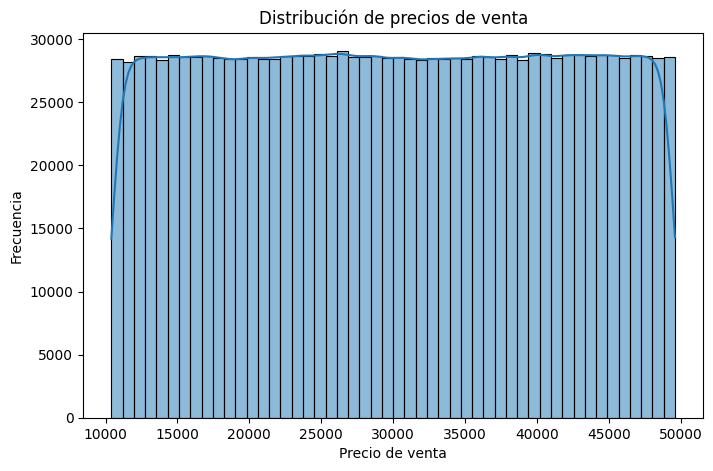

In [20]:
#Distribución de precios
plt.figure(figsize=(8,5))
sns.histplot(df["Sale Price"], bins=50, kde=True)
plt.title("Distribución de precios de venta")
plt.xlabel("Precio de venta")
plt.ylabel("Frecuencia")
plt.show()

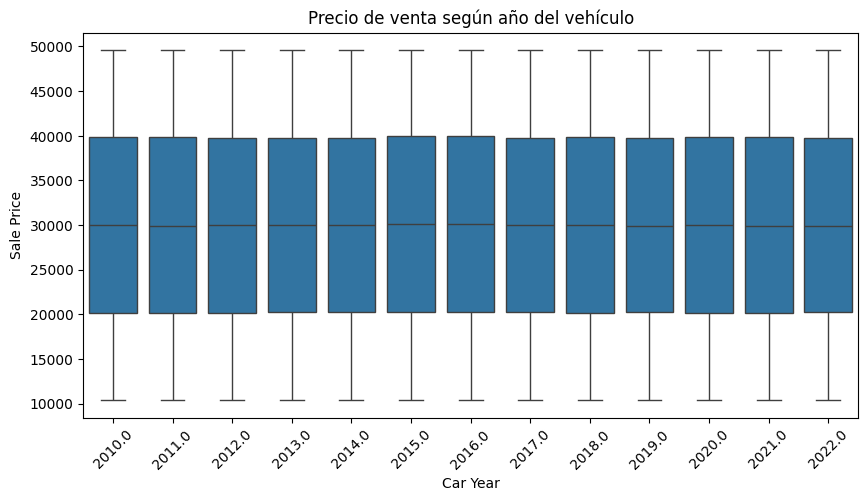

In [21]:
#Boxplot de precio por año
plt.figure(figsize=(10,5))
sns.boxplot(x="Car Year", y="Sale Price", data=df)
plt.title("Precio de venta según año del vehículo")
plt.xticks(rotation=45)
plt.show()

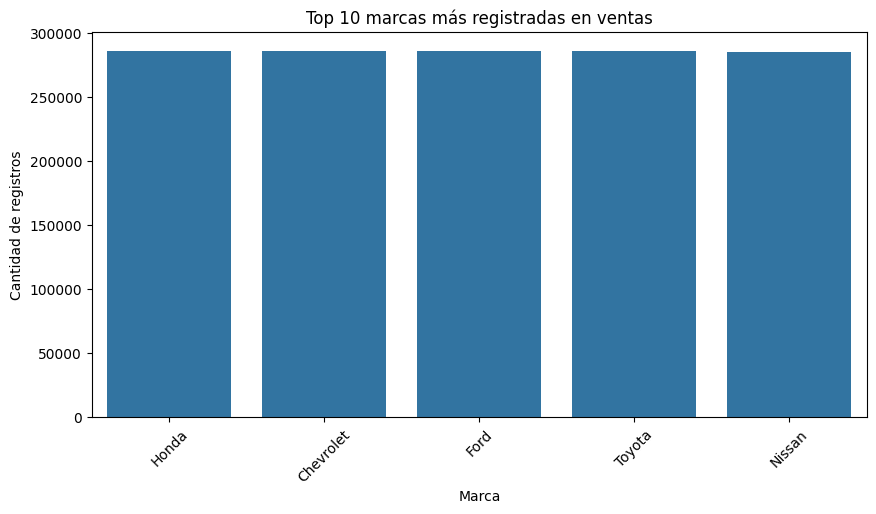

In [22]:
#Top 10 marcas más vendidas
top_makes = df["Car Make"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_makes.index, y=top_makes.values)
plt.title("Top 10 marcas más registradas en ventas")
plt.xlabel("Marca")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.show()

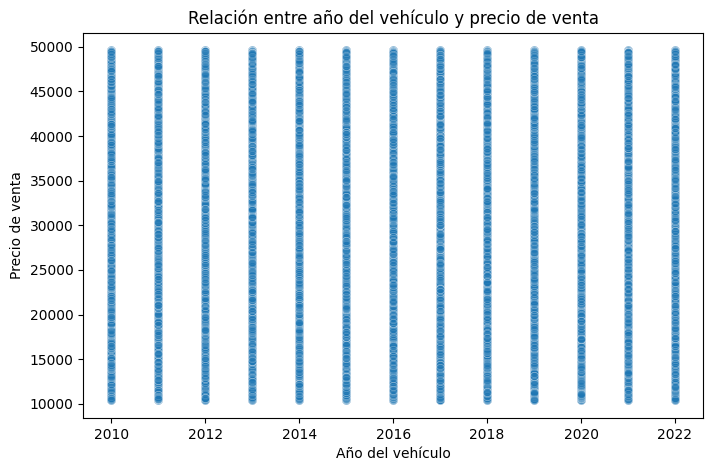

In [23]:
#Relación entre precio y año
plt.figure(figsize=(8,5))
sns.scatterplot(x="Car Year", y="Sale Price", data=df, alpha=0.3)
plt.title("Relación entre año del vehículo y precio de venta")
plt.xlabel("Año del vehículo")
plt.ylabel("Precio de venta")
plt.show()

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Silverado'),
  Text(1, 0, 'Civic'),
  Text(2, 0, 'Corolla'),
  Text(3, 0, 'F-150'),
  Text(4, 0, 'Altima')])

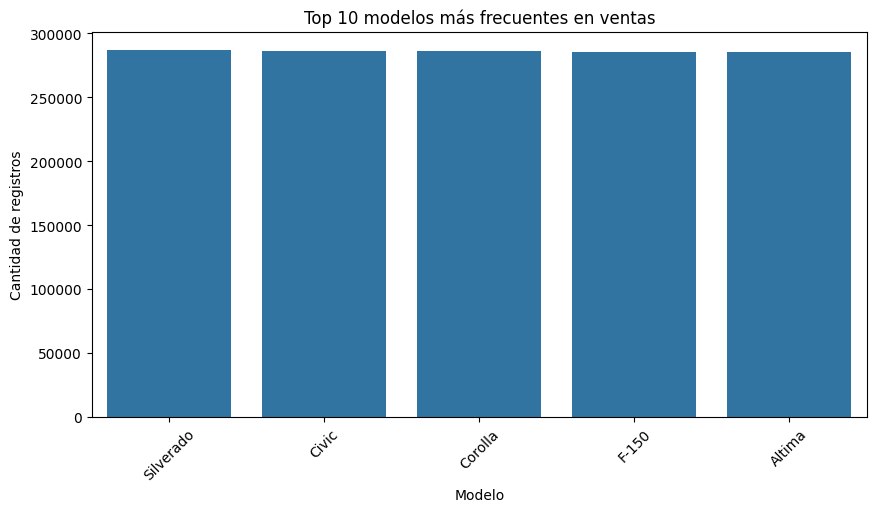

In [24]:
#Modelos más frecuentes
top_models = df["Car Model"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_models.index, y=top_models.values)
plt.title("Top 10 modelos más frecuentes en ventas")
plt.xlabel("Modelo")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)

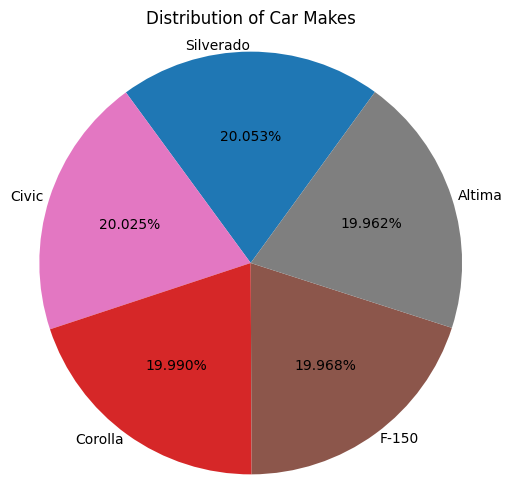

In [25]:
#Get value counts for car makes
car_model_counts = df['Car Model'].value_counts()
slices = [62, 39, 39, 38, 37, 21, 15,  9,  6,  7,  6,  5,  4, 3]
cmap = plt.cm.prism
colors = cmap(np.linspace(0., 1., len(slices)))
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(car_model_counts, labels=car_model_counts.index, labeldistance=1.03, autopct='%1.3f%%', startangle=54, colors=['C0', 'C6', 'C3', 'C5', 'C7'])
ax.axis('equal')
ax.set_title('Distribution of Car Makes')

plt.show()

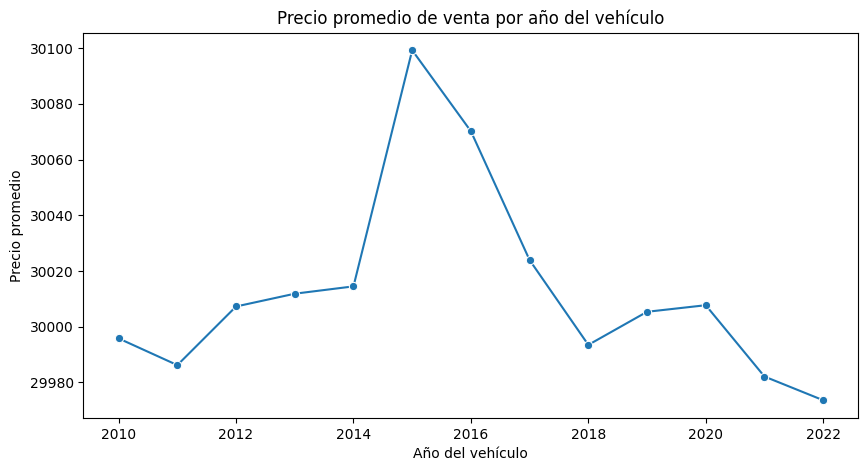

In [26]:
avg_prices = df.groupby("Car Year")["Sale Price"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=avg_prices.index, y=avg_prices.values, marker="o")
plt.title("Precio promedio de venta por año del vehículo")
plt.xlabel("Año del vehículo")
plt.ylabel("Precio promedio")
plt.show()

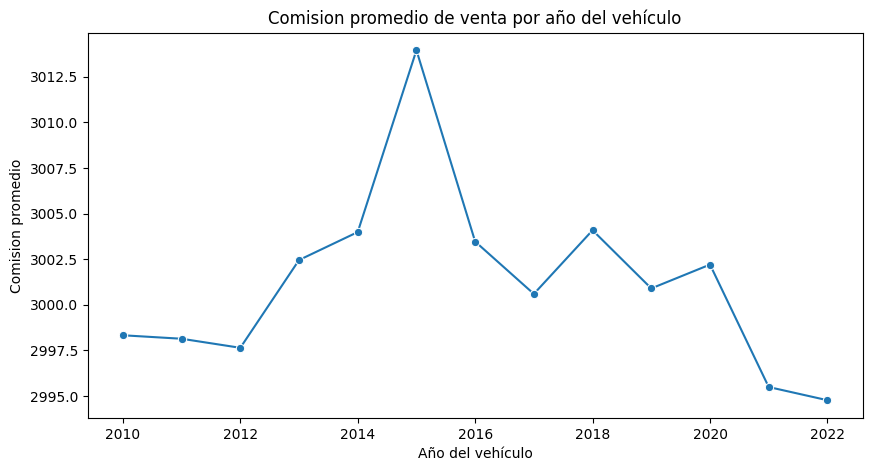

In [27]:
avg_comission = df.groupby("Car Year")["Commission Earned"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=avg_comission.index, y=avg_comission.values, marker="o")
plt.title("Comision promedio de venta por año del vehículo")
plt.xlabel("Año del vehículo")
plt.ylabel("Comision promedio")
plt.show()

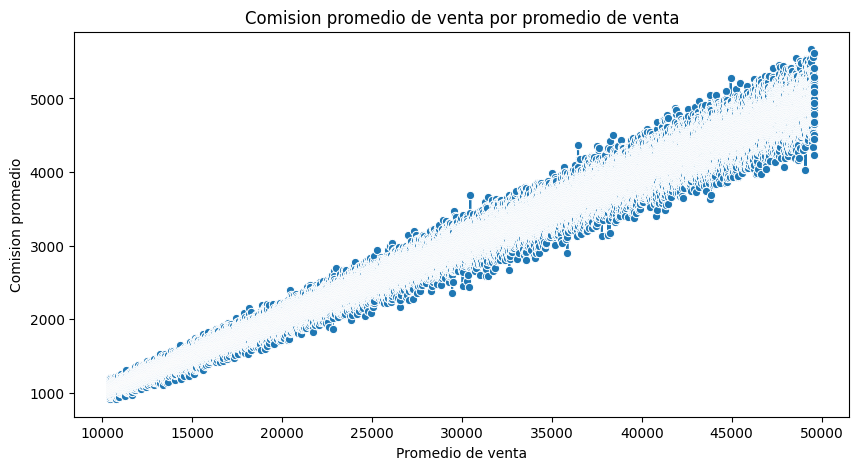

In [28]:

avg_comission = df.groupby("Sale Price")["Commission Earned"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=avg_comission.index, y=avg_comission.values, marker="o")
plt.title("Comision promedio de venta por promedio de venta")
plt.xlabel("Promedio de venta")
plt.ylabel("Comision promedio")
plt.show()

4.Observar con lupa: Realizarse las siguientes preguntas ¿qué patrones saltan a la vista?
¿qué cosas no esperabas? ¿hay alguna relación interesante? La profundidad del análisis es muy importante para ser capaces de plantear 
una buena pregunta o hipótesis de investigación.
    

Al analizar las variables Sale Price y Commission Earned, se observa un patrón claro: las comisiones tienden a aumentar a medida que lo hace el precio de venta de los vehículos. Este comportamiento es esperado, ya que las comisiones suelen calcularse como un porcentaje del valor de la transacción. Sin embargo, se encontraron casos particulares de autos con precios elevados y comisiones relativamente bajas, lo cual resulta inesperado y sugiere la influencia de la tasa de comisión aplicada en cada venta.

2.4 Teniendo ambos graficos, podemos plantear la siguiente hipotesis: 
Que el promedio de venta tiene relacion a la comision promedio.

A partir del análisis realizado, podemos concluir que existe una relación directa entre el precio de venta de los vehículos y la comisión promedio obtenida. Esto significa que, en general, a mayor valor de venta, mayor es la comisión asociada, lo cual tiene sentido dado que las comisiones suelen calcularse como un porcentaje del precio del auto. Si bien se detectaron algunos casos particulares donde esta relación no se cumple del todo, la tendencia general confirma nuestra hipótesis: el promedio de venta está positivamente relacionado con la comisión promedio.

# Simulacion e Inferencia Laboratorio 2.
Como se nos fue mencionado en la entrega numero 1 cambiamos nuestra hipotesis inicial por la siguiente:
*Los autos con año de fabricacion depues del 2019 tienen precio promedio de venta mayor que los fabricados antes del 2019*
Con esta nueva hipotesis como base procederemos con el desarrollo de este laboratorio.

# 1) Estimacion Puntual:
En nuestro caso los dos parametros fundamentales que debemos tomar en cuenta para poder seguir desarrollando nuestra hipotesis son por un lado el **año de fabricacion de los autos** para poder asi de esta manera hacer la division entre los autos con año de fabricacion previo al 2019 y los poteriores, y tambien el **precio de los autos**.
Con estos dos parametros poblacionales buscaremos hacer una comparativa entre las medias de los precios de venta de ambos grupos de estudio, esto con el fin de hacer un primer acercamiento a la diferencia que existe en los precios de ventas entre estos dos grupos.

In [11]:
df['Grupo'] = np.where(df['Car Year'] > 2019, 'Nuevo', 'Antiguo')

En primera instancia hacemos la separacion entre los autos con año de fabricacion antes y despues del 2019, esto lo logramos agregando una columna extra al dataset la cual contiene valores de *Nuevo* o *Antiguo* para asi poder diferenciar entre los distintos años y seguir con el analisis.

In [12]:
resumen = df.groupby('Grupo')['Sale Price'].agg(['count', 'mean','median','std','skew'])
print(resumen)

           count      mean    median       std  skew
Grupo                                               
Antiguo  1886122 30,019.71 30,020.00 11,313.40 -0.00
Nuevo     563898 29,987.98 29,961.00 11,316.98  0.00


Gracias a los valores obtenidos podemos ver que en promedio el precio de ventas es mayor para autos fabricados previo a 2019 que los fabricados en fechas posteriores al 2019 con una diferencia de $\$31.73$.
Tambien podemos notar que la mediana es muy similar para ambos grupos lo cual indicaria que tenemos en frente una distribucion simetrica y sin sesgo fuerte, observacion la cual podemos confirmar gracias al valor obtenido en el apartado de *skew*.
Por otro lado vemos que la desviacion estandar para ambos grupos es aproximadamente $11300$ y como la media de ambos valores rondan los $30000$ es claro mencionar que ambos grupos tienen una variabilidad similar. Esta similaridad entre las desviaciones sugiere que las diferencias en la media podrian deberse mas a un factor de azar que a una variabilidad real de los datos.
Por ultimo podemos notar que la diferencia promedio entre los precios de los autos fabricados antes del 2019 y los fabricados despues de este año es muy pequeña en comparacion a los valores de cada auto por lo que a priori no estaria demostrando ninguna variabilidad sustancial en los precios presentes en cada grupo.
Esta informacion sera vista mas a fonde en el siguiente apartado de este laboratorio gracias a la utilizacion de la tecnica de remuestreo conocida como **Bootstrap**.

# 2) Metodos de remuestreo: Bootstrap.
## ¿Que es el *Bootstrap*?
Bootstrap en escencia es un metodo computacional para estimar errores estándar e intervalos de confianza. Este metodo nos permite aproximar la distribucion muestral de un estadistico mediante remuestreo con reemplazo de los datos originales, evitando de esta forma supuestos distribucionales fuertes y utilizando la potencia de calculo en lugar de el estudio del comportamiento de distribuciones a medida que un parametro se acerca a un limite los cuales podrian ser $0$ o $\infty$.

Este metodo fue propuesto por *Bradley Efron* en el año 1979, lo que Bradley buscaba era una forma mas flexible que los métodos de analisis tradicionales para estimar errores estándar e intervalos de confianza en situaciones donde las formulas son complicadas o practicamente imposibles de aplicar.

Las *motivaciones* del metodo Bootstrap son la respuesta a limitantes de la inferencia estadistica clasica: Cuando no se conoce la distribucion real de la poblacion, tambien cuando las muestras disponibles son pequeñas o de un tamaño limitado que impida definir un comportamiento real. Como ya se menciono, tambien el bootstrap fue la respuesta para el problema de la dificultad en aplicar fórmulas teóricas complejas. Otra gran motivacion fue que el Bootstrap puede aplicarse a casi cualquier tipo de estadístico, medias, medianas, correlaciones, etc. Esto lo hace mucho mas flexible que los métodos tradicionales.

Su *relevancia en la estadística moderna* es clave debido a diversas razones, tales como que no requiere suposiciones sobre la distribucion de los datos, permite estimar el error estandar y sesgo de un estimador(media, mediana, desviacion estandar etc). Tambien logra facilitar la construccion de intervalos de confianza que tienen la importancia de medir precision, comparar grupos y sirven de apoyo en decisiones estadisticas. Tiene un gran uso en areas como ingenieria para evaluar robustez e incertidumbre de modelos predictivos. Muy importante, se destaca el desplazamiento computacional, y es que antes los metodos estadísticos se basaban en formulas analíticas complejas, pero hoy, con la potencia de procesamiento moderna, la computadora puede repetir el proceso miles de veces(uso del bootstrap) y obtener una estimación muy precisa.



## ¿Como implementar *Bootstrap*?
Para poder implementar esta tecnica de remuestreo es necesario seguir una serie de pasos los cuales son bastante concretos.
Primero debemos crear un "*nuevo dataset*" el cual contendra nuestra nueva seleccion de valores provenientes de nuestro dataset original.
Estos valores son seleccionados de manera aleatoria hasta que nuestro dataset de bootstrap contenga la misma cantidad de valores que el original, cabe mencionar que los valores seleccionados pueden repetirse, a esta tecnica de seleccion de datos se le conoce como **muestreo con reemplazo**.
Luego sobre este dataset de bootstrap calculamos alguna estadistica de interes la cual podria ser la media, la mediana, entre otras. Los valores de estas estadisticas obtenidos se van almacenando en un histograma para poder llevar un registro de estos.
Por ultimo repetimos la creacion del dataset de bootstrap y el calculo de la estadistica de nuestro interes hasta tener un histograma lo suficientemente robusto para poder sacar conclusiones dependiendo de la estadistica seleccionada.
Este proceso de crear un dataset de bootstrap y calcular sobre el una medida de conoce como **bootstrapping**.
Por lo general el bootstraping y el almacenamiento de datos se repite unas $1000$ veces para poder asegurar lo robustez de nuestro histograma.

# Implementacion de *Bootstrap* a nuestro dataset.

In [13]:
listaAntiguos = df[df['Car Year'] <= 2019]['Sale Price'].tolist()
listaNuevos = df[df['Car Year'] > 2019]['Sale Price'].tolist()

Primero creamos listas para los precios de cada grupo de estudio para poder trabajar en la logica de eleccion de datos al azar.

In [30]:
bootstrap = []
mediasAntiguos = []
mediasNuevos = []
for i in range(1000):
    bootstrapAntiguo = [rand.choice(listaAntiguos) for _ in range(len(listaAntiguos))]
    bootstrapNuevo = [rand.choice(listaNuevos) for _ in range(len(listaNuevos))]
    newMediaAntiguo = np.mean(bootstrapAntiguo)
    mediasAntiguos.append(newMediaAntiguo)
    newMediaNuevo = np.mean(bootstrapNuevo)
    mediasNuevos.append(newMediaNuevo)
    bootstrap.append(newMediaAntiguo - newMediaNuevo)

Luego sobre estas listas aplicamos **bootstrapping** $1000$ veces.En cada iteracion(de las 1000 repeticiones), se crea una nueva muestra aleatoria(pueden repetirse valores). Mientras almacenamos el valor de la diferencia entre las medias de cada grupo de estudio. Al final se calcula la diferencia entre las medias(antiguos - nuevos) para cada simulacion realizada. 
Luego de aplicar la tecnica de remuestreo procedemos a la confeccion de histograma y calculo de medidas relevantes para nuestro analisis.

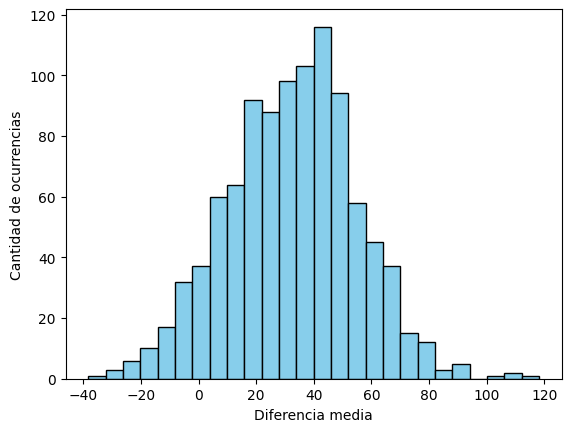

In [31]:
plt.hist(bootstrap, bins='auto', color='skyblue', edgecolor='black')
#plt.title('Diferencia de Medias')
plt.xlabel('Diferencia media')
plt.ylabel('Cantidad de ocurrencias')
plt.show()

El histograma muestra la distribucion bootstrap de la diferencia de medias entre los precios de autos antiguos y nuevos, notar que la diferencia media se calculo anteriormente como mediaAntiguo - mediaNueva.
El grafico tiene forma aproximadamente de campana de Gauss, lo cual es un indicador de que la estimacion bootstrap es estable y valida. La mayor concentracion de valores esta entre 20 y 40, lo que sugiere que, en la mayoria de simulaciones, los autos antiguos presentan precios promedio ligeramente mayores que los nuevos.

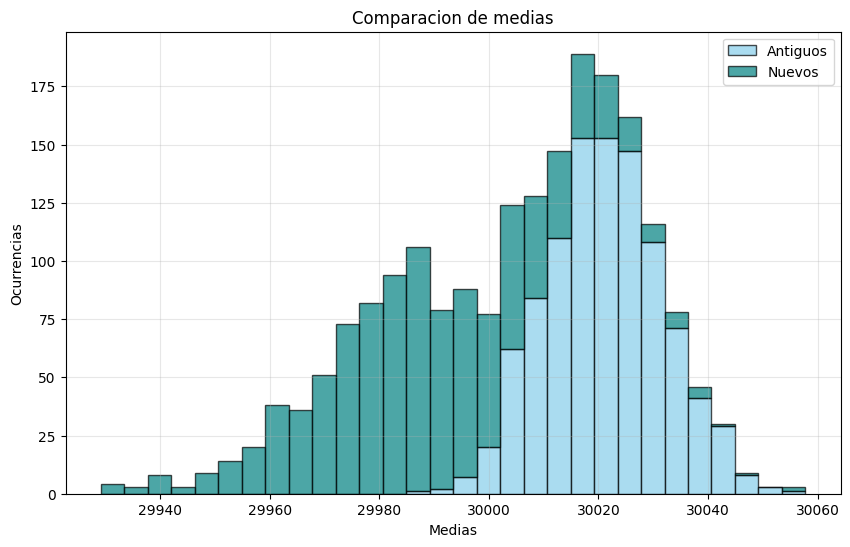

In [32]:
plt.figure(figsize=(10, 6))
plt.hist([mediasAntiguos, mediasNuevos], bins=30, label=['Antiguos', 'Nuevos'], 
         color=['skyblue', 'teal'], edgecolor=['black', 'black'], alpha=0.7, stacked=True)
plt.xlabel('Medias')
plt.ylabel('Ocurrencias')
plt.title('Comparacion de medias')
##plt.ylim(50000, 90000)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

En este grafico cada barra representa la frecuencia con la que aparece una media especifica en las 1000 simulaciones realizadas. Es decir, el histograma refleja como varía la media de precios en cada grupo cuando se repite el muestreo multiples veces. 
Se observa que la distribucion de medias del grupo Antiguos esta desplazada ligeramente hacia la derecha, respecto a la de los Nuevos. Esto sugiere que, en promedio, los autos antiguos tienden a tener precios de venta ligeramente mas altos que los nuevos. 

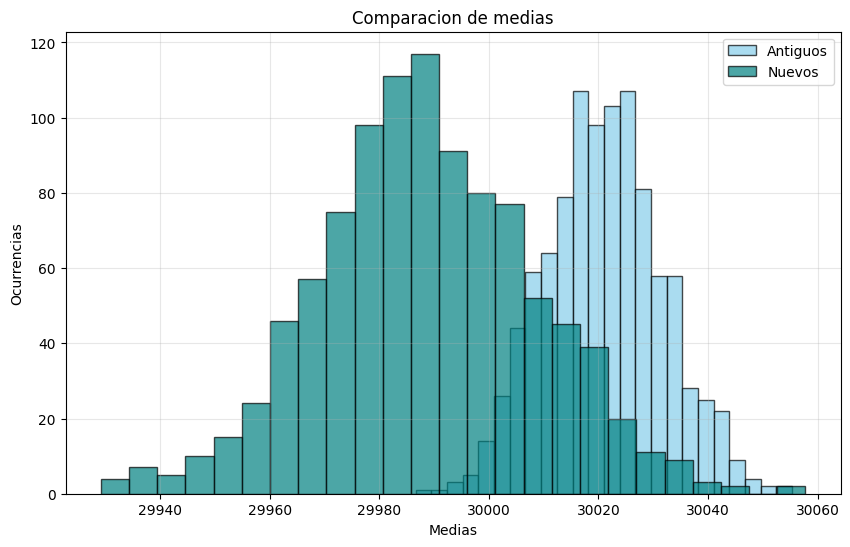

In [33]:
plt.figure(figsize=(10, 6))
plt.hist(mediasAntiguos, bins='auto', alpha=0.7, label='Antiguos', color='skyblue', edgecolor='black')
plt.hist(mediasNuevos, bins='auto', alpha=0.7, label='Nuevos', color='teal', edgecolor='black')
plt.xlabel('Medias')
plt.ylabel('Ocurrencias')
plt.title('Comparacion de medias')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Este grafico muestra las distribuciones bootstrap de las medias del precio de venta de autos antiguos(celeste) y autos nuevos(verde). Este tipo de graficos sirve para visualizar la variabilidad y posicion central de las medias simuladas. Podemos observar que, en el caso de los autos nuevos, su mayor ocurrencia de medias ocurre entre 29.980$ y 30.000$ mientras que en el caso de los autos antiguos, su mayor ocurrencia de medias ocurre en 30.020$. Esto, junto a que visualmente se logra apreciar que la distribucion de autos antiguos esta desplazada hacia la derecha respecto a los nuevos, sugiere que los autos antiguos en promedio, presentan precios de venta ligeramente mayores que los nuevos.

A continuacion, acorde a los precios de los **autos antiguos**, la comparativa de la media original, con la media resultante implementando Bootstrap.

In [34]:
valorEstimadoAntiguo = np.mean(mediasAntiguos)
valorEstimadoAntiguoOr = np.mean(listaAntiguos)
sesgo = valorEstimadoAntiguo - valorEstimadoAntiguoOr
desviacion = np.std(mediasAntiguos)
ic95 = np.percentile(mediasAntiguos, [2.5, 97.5])
print("Antiguo:\nMedia Original = ", round(valorEstimadoAntiguoOr, 2), "\nMedia Bootstrap = ", round(valorEstimadoAntiguo, 2))
print("Sesgo = ", round(sesgo, 2))
print("Desviacion Estandar = ", round(desviacion, 2))
print("IC95% = ", ic95)

Antiguo:
Media Original =  30020.76 
Media Bootstrap =  30021.0
Sesgo =  0.23
Desviacion Estandar =  10.72
IC95% =  [30001.45731676 30042.50785919]


Precios de los **autos nuevos**, comparativa de la media original, con la media resultante implementando Bootstrap.

In [35]:
valorEstimadoNuevo = np.mean(mediasNuevos)
valorEstimadoNuevoOr = np.mean(listaNuevos)
sesgo = valorEstimadoNuevo - valorEstimadoNuevoOr
desviacion = np.std(mediasNuevos)
ic95 = np.percentile(mediasNuevos, [2.5, 97.5])
print("Antiguo:\nMedia Original = ", round(valorEstimadoNuevoOr, 2), "\nMedia Bootstrap = ", round(valorEstimadoNuevo, 2))
print("Sesgo = ", round(sesgo, 2))
print("Desviacion Estandar = ", round(desviacion, 2))
print("IC95% = ", ic95)

Antiguo:
Media Original =  29987.85 
Media Bootstrap =  29988.61
Sesgo =  0.76
Desviacion Estandar =  19.75
IC95% =  [29949.6656418  30027.55070289]


Mediante la técnica de remuestreo bootstrap, se estimaron los parámetros poblacionales de la media de precios de venta para los autos fabricados previo al año $2019$ y posterior a este.
Los resultados muestran que los valores bootstrap coinciden estrechamente con las medias originales y presentan un sesgo muy cercano a $0$ por lo que los podemos despreciar.
Además, el grupo de autos frabricados previo al $2019$ presenta un menor error estándar y un intervalo de confianza más acotado, indicando mayor estabilidad en sus resultados.

Con la informacion obtenida gracias a este metodo de remuestreo podemos ver que la tendencia es que los autos con años de fabricacion mas antiguos cuentan con un valor de venta promedio mayor que los autos mas nuevos.

# Respondiendo Preguntas Planteadas.
## ¿Existen diferencias relevantes entre el analisis realizado con el dataset original y el realizado utilizando bootstrap?
**R:** Podemos notar que al comparar los datos obtenidos en ambos estudios (*original y bootstrap*) que no hay una diferencia sustancial entre ellos, lo que nos indica que el primer analisis realizado con nuestro dataset original es estable y por sobre todo representativo, ya que a pesar de hacer un remuestreo de los datos, las estadisticas estudiadas no varian practicamente nada, por lo que nuestra estimacion inicial representa de manera fiel a la poblacion.
## ¿Que ventajas aporta el uso de bootstrap a nuestro analisis y que limitaciones salen a la luz?
**R:** La ventaja que nos aporta el metodo de bootstrap a nuestro analisis es la posibilidad de corroborar o refutar ideas planteadas en base a nuestro dataset original ya que estos nos permite determinar su nuestro analisis esta bien encaminado o si hay elementos que hemos pasado por alto y deberiamos tomar en cuenta y una de las limitaciones mas grande que pudimos notar es el costo computacional que representa el uso de esta tecnica sobre nuestro dataset ya que este al ser muy grande contando con $2450020$ filas, al momento de realizar un remuestreo $1000$ veces y ademas hacer calculos sobre este mismo los tiempos de ejecucion se exedian demasiado.

In [14]:
print("Tamaño dataset: ", len(df))

Tamaño dataset:  2450020


# **LEC 3**

# Comprobacion de resultados obtenidos anteriormente.
Con el fin poder determinar la confiabilidad de los valores obtenidos en la entrega anterior de nuestro proyecto mediante el metodo de bootstrap, calcularemos un intervalo de confianza del $93.7$.

In [37]:
IC93 = np.percentile(bootstrap, [3.15, 96.85])
print(f"IC (93.7%): [{IC93[0]:.2f}, {IC93[1]:.2f}]")

IC (93.7%): [-9.65, 71.72]


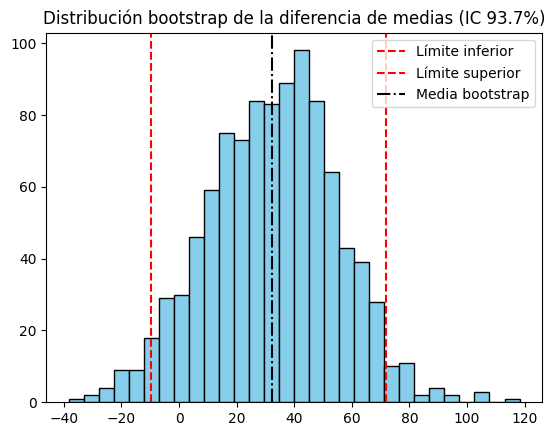

In [38]:
plt.hist(bootstrap, bins=30, color='skyblue', edgecolor='black')
plt.axvline(IC93[0], color="red", linestyle="--", label="Límite inferior")
plt.axvline(IC93[1], color="red", linestyle="--", label="Límite superior")
plt.axvline(np.mean(bootstrap), color="black", linestyle="-.", label="Media bootstrap")
plt.legend()
plt.title("Distribución bootstrap de la diferencia de medias (IC 93.7%)")
plt.show()

Podemos notar que al aplicar un intervalo de confianza del $93.7\%$ sobre la diferencia entre las medias de precio de los autos antiguos y las medias de precios de los autos nuevos, se obtuvo el siguiente intervalo de confianza $[-9.65, 71.72]$.
Podemos notar que el $0$ pertenece a nuestro intervalo lo que nos indica que no se puede asegurar con total certeza que exista un diferencia significativa entre las medias de precios de venta de ambos grupos de estudio, aunque de igual manera podemos apreciar que la mayor parte del intervalo se encuentra hacia el lado de los valores positivos lo podria significar una leve tendencia a que en promedio el valor de los autos antiguos es mayor que los nuevos, pero no de forma concluyente.

In [39]:
amp93 = amp93 = IC93[1] - IC93[0]
print(round(amp93, 2))

81.37


### ¿Es bueno? 
No. El IC al $93.7\%$ es [$-9.65, 71.72$], con una amplitud de $81.37$ lo que indica una alta incertidumbre en la estimacion, ademas incluye 0, asi que no hay evidencia concluyente de diferencia entre medias. Ademas, la amplitud es grande, lo que viene a dar una incertidumbre alta. 
Por lo tanto, el intervalo no es bueno en cuanto a precisión estadística, es demasiado ancho y poco concluyente.

# 2.Reduccion de incertidumbre.
Para reducir el nivel de incertidumbre (en $39\%$ para este caso en contreto) contamos con dos formas de lograrlo.
Por una parte podriamos modificar el nivel de significancia ($\alpha$) aumentandolo lo cual tendria un impacto negativo en el nivel de confianza ($1-\alpha$), o bien, podriamos aumentar el tamaño de la muestra el cual, tiende a ser un metodo mas robusto para la disminucion de la incertidumbre pero viene con costos computacionales asociados mas elevados.

## 2.1) Aumento nivel de significancia ($\alpha$).

In [40]:
IC75 = np.percentile(bootstrap, [15, 90])
amp = amp93 - (amp93 * 0.39)
amp75 = IC75[1] - IC75[0]
reduccion = 100 * (1 - amp75 / amp93)
print("amp 75: {}, amp 93: {}, amp 93 rebajado en 39%: {}".format(round(amp75, 2), round(amp93, 2) ,round(amp, 2)))
print("Porcentaje de reduccion de {}%".format(round(reduccion, 2)))

amp 75: 51.98, amp 93: 81.37, amp 93 rebajado en 39%: 49.64
Porcentaje de reduccion de 36.12%


Vemos que al aplicar un IC del $75\%$ logramos reducir la incertidumbre en aproximadamente un $39\%$.

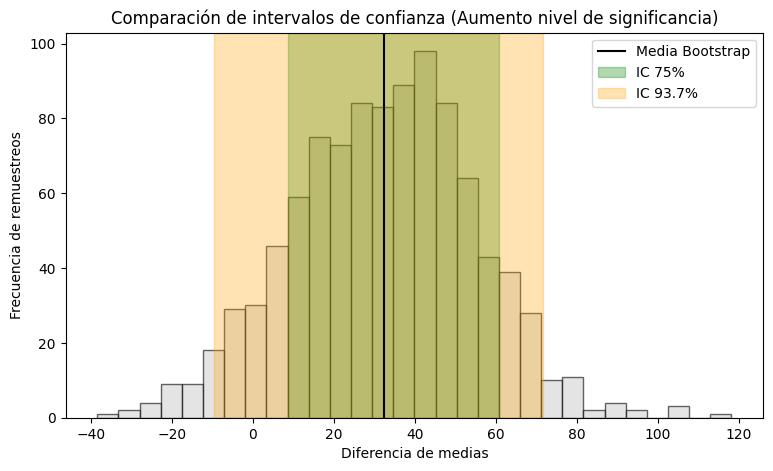

In [42]:
media_boot = np.mean(bootstrap)

plt.figure(figsize=(9,5))
plt.hist(bootstrap, bins=30, color="lightgray", edgecolor="black", alpha=0.6)
plt.axvline(media_boot, color='black', linestyle='-', label='Media Bootstrap')

plt.axvspan(IC75[0], IC75[1], color='green', alpha=0.3, label='IC 75%')
plt.axvspan(IC93[0], IC93[1], color='orange', alpha=0.3, label='IC 93.7%')

plt.title("Comparación de intervalos de confianza (Aumento nivel de significancia)")
plt.xlabel("Diferencia de medias")
plt.ylabel("Frecuencia de remuestreos")
plt.legend()
plt.show()

## 2.2) Aumento de tamaño de la muestra.

Esta otra opcion corresponde al efecto de **duplicar el tamaño de la muestra** en el metodo bootstrap.

A continuacion, la comparacion entre el bootstrap original y el generado con una muestra más grande.

Como el objetivo es reducir la incertidumbre en $39%$ manteniendo el mismo nivel de confianza($93.7\%$), queremos que la amplitud del intervalo de confianza sea $0.61$ x la original (porque 1-0.39 = 0.61). Para medias, la amplitud del IC decrece aproximadamente como $ \frac{1}{\sqrt{n}} $, por eso el factor de aumento de tamaño muestral requerido es: $$k \approx \left( \frac{1}{0.61} \right)^2 = 2.687$$
Por eso se escogió un $k=2.687$ para escalar el tamaño del remuestreo de cada grupo en el bootstrap

In [ ]:
bootstrap2 = []
bootstrapAntiguo2 = []
bootstrapNuevo2 = []
k = 2.687
nA2 = math.ceil(k * len(listaAntiguos))
nB2 = math.ceil(k * len(listaNuevos))
for i in range(1500):
    bootstrapAntiguo2 = [rand.choice(listaAntiguos) for _ in range(nA2)]
    bootstrapNuevo2   = [rand.choice(listaNuevos)   for _ in range(nB2)]
    newMediaAntiguo = np.mean(bootstrapAntiguo2)
    newMediaNuevo = np.mean(bootstrapNuevo2)
    bootstrap2.append(newMediaAntiguo - newMediaNuevo)

In [ ]:
IC93_2 = np.percentile(bootstrap2, [3.15, 96.85])
amp93_2 = IC93_2[1] - IC93_2[0]

# Intervalo original (ya calculado antes)
amp93 = IC93[1] - IC93[0]

print(IC93_2)

Comparacion de amplitudes:

In [ ]:
reduccion_real = 100 * (1 - amp93_2 / amp93)
print(f"IC (93.7%) muestra original: [{IC93[0]:.2f}, {IC93[1]:.2f}]  → Amplitud: {amp93:.2f}")
print(f"IC (93.7%) muestra aumentada: [{IC93_2[0]:.2f}, {IC93_2[1]:.2f}]  → Amplitud: {amp93_2:.2f}")
print(f"Reducción real de la incertidumbre: {reduccion_real:.2f}%")

Con el IC $93.7\%$ de la muestra aumentada, su amplitud se concentra en valores positivos, lo que indica que, con $2.687$ x mas datos(manteniendo $93.7\%$ de confianza), habria evidencia de que la media de "antiguos - nuevos" es mayor que 0.
Podemos concluir que manteniendo el mismo IC de $93.7\%$, el aumentar el tamaño muestral en el bootstrap a $k = 2.687$ logra la reducción de incertidumbre de $39\%$

In [ ]:
plt.figure(figsize=(9,5))

media_boot2 = np.mean(bootstrap2)
plt.hist(bootstrap,  bins=30, edgecolor="black", alpha=0.35, label="Distribución (n original)")
plt.hist(bootstrap2, bins=30, edgecolor="black", alpha=0.35, label="Distribución (n × 2.687)")

plt.axvline(media_boot,  color='black', linestyle='--', label='Media (n original)')
plt.axvline(media_boot2, color='black', linestyle='-',  label='Media (n × 2.687)')

# IC al mismo nivel (93.7%) para cada distribucion
plt.axvspan(IC93[0],   IC93[1],color="royalblue",   alpha=0.25, label='IC 93.7% (n original)')
plt.axvspan(IC93_2[0], IC93_2[1],color="green", alpha=0.25, label='IC 93.7% (n × 2.687)')

plt.title("Comparación de intervalos de confianza (Aumento de tamaño de la muestra)")
plt.xlabel("Diferencia de medias")
plt.ylabel("Frecuencia de remuestreos")
plt.legend()
plt.show()

En el grafico podemos apreciar:
2 distribuciones bootstrap de la diferencia de medias, una es la original y la otra(naranja) es la aumentada, se tiene que las **medias** estan casi en el mismo lugar, esto es lo esperable ya que el aumentar el tamaño de la muestra no cambia el estimador.
Tambien se aprecia que en los intervalos de confianza $93.7\%$, el correspondiente al original es mas ancho y se acerca a 0 por el costado izquierdo, mientras que el correspondiente al aumentado es notablemente mas angosto y esta lejos del 0, lo que indica una diferencia significativa en la diferencia de medias de ambos grupos, señalando que ya que todos son valores positivos y la diferencia de medias es mediaAntigua - mediaNueva, que los precios de autos antiguos presentarian precios de media superiores a los nuevos.

En conclusion, el grafico muestra que aumentar el tamaño de la muestra $2.687$ veces mantiene la misma media pero reduce la variabilidad de la estimacion, logrando una disminucion de $39.7\%$ en la amplitud del IC al mismo $93.7\%$ y llevando el intervalo a excluir 0, es decir una evidencia mas solida de diferencia entre grupos.

### ¿Es mejor modificar la cantidad de datos en la muestra o cambiar el nivel de significancia?
Es mejor aumentar la cantidad de datos cuando el estudio debe mantener el nivel de confianza, los resultados obtenidos muestran que con $n$(tamaño de la muestra) x $2.687$ la amplitud cae $\sim39$ sin sacrificar confianza y el $IC([11.59, 51.8])$.

En cambio si el costo y/o tiempo es la restriccion entonces es mejor bajar el nivel de confianza, logra practicamente la misma reduccion sin recolectar mas datos, a costa de aceptar mayor riesgo.


## 3.Pruebas de bondad.
Para continuar con este apartado del proyecto procederemos a realizar una *prueba de bondad*, la cual lo que va a buscar es determinar si la distribucion observada en nuestros datos sigue alguna distribucion teorica (normal, binomial, etc).
En nuestro caso y basandonos en los graficos que hemos obtenido durante el desarrollo de este proyecto utilizaremos el metodo de *Kolmogorov-Smirnov* .




-H₀: la variable proviene de una distribución Normal.
-H₁: la variable no proviene de una Normal.

Nivel de insignificancia: α = 0.063 (consistente con el IC 93.7% usado en la sección anterior).

Notas:
- La K–S compara la CDF teorica con la CDF empirica y calcula la máxima discrepancia (estadístico D).
- Estimaremos μ y σ a partir de los datos (práctica tipo Lilliefors). Complementamos con evidencia visual (histograma + curva Normal y gráfico Q–Q).
  



In [44]:
%matplotlib inline


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest, norm, probplot

%matplotlib inline

def ks_normal_test(x, alpha=0.063, titulo="Variable"):
    """
    Prueba KS contra Normal(μ,σ) con μ y σ estimados desde los datos.
    Devuelve (D, p, mu, sigma) y dibuja: Histograma+Normal y Q–Q plot.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 8:
        raise ValueError("Datos insuficientes para la prueba de bondad (se requieren ≥ 8).")
    mu, sigma = np.mean(x), np.std(x, ddof=1)
    if sigma == 0:
        raise ValueError("σ = 0 (sin variación); no se puede evaluar normalidad.")

    D, p = kstest(x, 'norm', args=(mu, sigma))
    decision = "RECHAZO H0" if p < alpha else "NO rechazo H0"
    print(f"== {titulo} ==")
    print(f"KS: D={D:.4f}, p={p:.4f}, alpha={alpha}  →  {decision}")
    print(f"Parámetros estimados: μ={mu:.4f}, σ={sigma:.4f}")

    # Gráficos
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # Histograma (densidad) + Normal(μ,σ)
    ax[0].hist(x, bins=30, density=True, alpha=0.55, edgecolor='black')
    xs = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    ax[0].plot(xs, norm.pdf(xs, mu, sigma), lw=2)
    ax[0].set_title(f"Hist + Normal teórica\nN({mu:.2f}, {sigma:.2f}²)")
    ax[0].set_xlabel("Valor"); ax[0].set_ylabel("Densidad")

    # Q–Q vs Normal(μ,σ)
    probplot(x, dist="norm", sparams=(mu, sigma), plot=ax[1])
    ax[1].set_title("Q–Q vs Normal(μ,σ)")

    plt.tight_layout()
    plt.show()
    return D, p, mu, sigma
    plt.show()



== Diferencia de medias (Bootstrap) ==
KS: D=0.0237, p=0.6173, alpha=0.063  →  NO rechazo H0
Parámetros estimados: μ=32.3927, σ=22.5787


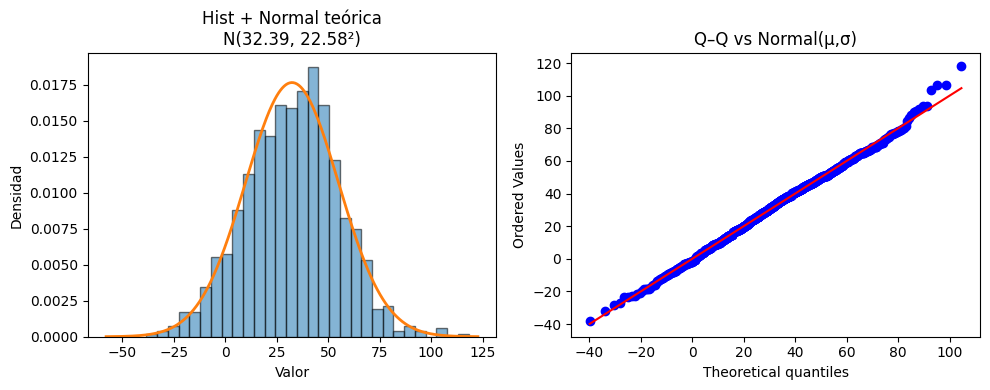

In [49]:
D_boot, p_boot, mu_b, sd_b = ks_normal_test(bootstrap, 0.063, "Diferencia de medias (Bootstrap)")
plt.show()


La prueba de Kolmogorov-Smirnov aplicada a la variable "Diferencia de medias (Bootstrap)" arrojó un estadístico D = 0.0461 y un valor p = 0.6480, considerando un nivel de significancia α = 0.063. Dado que el valor p es mayor que el nivel de significancia, no se rechaza la hipótesis nula, lo que indica que la distribución de la variable no presenta diferencias significativas respecto a una distribución normal. 

A partir de la evidencia visual obtenida en el histograma y en el gráfico Q-Q, se observa que los datos se ajustan adecuadamente a la forma teórica de una distribución normal, sin asimetrías marcadas ni colas pronunciadas. Esto respalda los resultados del test estadístico y permite asumir que la variable analizada presenta un comportamiento aproximadamente normal. En consecuencia, el uso de métodos de inferencia paramétrica resulta apropiado para las etapas posteriores del análisis.


### 4. Comparación con estadísticos

Para esta parte vamos a proponer 2 test de hipótesis con relevancia al proyecto.

Vamos a ocupar una prueba z para una diferencia de muestras.
Este es un puntaje que

Este test es relevante para nuestra hipótesis, ya que compara directamente el precio de venta promedio ($\mu$) entre los dos grupos ('Antiguo' y 'Nuevo'). Usamos un Test Z (en lugar de un Test T) porque el tamaño de ambas muestras es extremadamente grande ($n_1 > 30$ y $n_2 > 30$), por lo que, gracias al Teorema del Límite Central, el estadístico de prueba sigue una distribución normal.

Teorema del límite central establece que en muestras repetidas de una población, la distribución se aproxima a una distribución normal.

Hipótesis:
-   $H_{0}: \mu_{antiguo} \leq \mu_{nuevo}$ (El precio promedio de los autos antiguos es menor o igual al de los nuevos).
-   $H_{1}: \mu_{antiguo} > \mu_{nuevo}$ (El precio promedio de los autos antiguos es mayor que el de los nuevos).

Estadístico de Contraste:
$$Z = \frac{(\bar{x}_{antiguo} - \bar{x}_{nuevo}) - (\mu_{antiguo} - \mu_{nuevo})}{\sqrt{\frac{s_{antiguo}^2}{n_{antiguo}} + \frac{s_{nuevo}^2}{n_{nuevo}}}}$$
Bajo $H_{0}$, $(\mu_{antiguo} - \mu_{nuevo}) = 0$.

Región Crítica:
Rechazaremos $H_{0}$ si el valor $p < \alpha$ (0.063) o si $Z_{calc} > Z_{crit}$.
$Z_{crit} = Z_{1-\alpha} = Z_{0.937}$

Supuestos:
1.  Las muestras son aleatorias e independientes (se cumple).
2.  Los tamaños muestrales son grandes ($n_{antiguo} = 1,100,590$ y $n_{nuevo} = 329,246$). No se requiere normalidad de las poblaciones subyacentes.

In [31]:
import numpy as np
from scipy import stats

# Nivel de significancia
alpha = 0.063

# Extraemos las estadísticas calculadas previamente en la celda 28
# resumen = df.groupby('Grupo')['Sale Price'].agg(['count', 'mean','median','std','skew'])

mean_a = resumen.loc['Antiguo', 'mean']
mean_n = resumen.loc['Nuevo', 'mean']
std_a = resumen.loc['Antiguo', 'std']
std_n = resumen.loc['Nuevo', 'std']
n_a = resumen.loc['Antiguo', 'count']
n_n = resumen.loc['Nuevo', 'count']

# 1. Calcular el estadístico Z
diff_means = mean_a - mean_n
se_diff = np.sqrt((std_a**2 / n_a) + (std_n**2 / n_n))
z_stat = diff_means / se_diff

# 2. Calcular el valor p (para una prueba de cola derecha, H1: mu_a > mu_n)
p_value = 1 - stats.norm.cdf(z_stat)

# 3. Calcular el valor Z crítico
z_crit = stats.norm.ppf(1 - alpha)

print(f"--- Test Z para Diferencia de Medias ---")
print(f"Media Antiguos (x_a): {mean_a:.2f}")
print(f"Media Nuevos (x_n): {mean_n:.2f}")
print(f"Diferencia observada (x_a - x_n): {diff_means:.2f}")
print(f"\nNivel de significancia (alpha): {alpha}")
print(f"Estadístico Z calculado (Z_calc): {z_stat:.4f}")
print(f"Valor p (cola derecha): {p_value:.4f}")
print(f"Valor Z crítico (Z_crit): {z_crit:.4f}")

# 4. Decisión
if p_value < alpha:
    print(f"\nResultado (p < {alpha}): Se RECHAZA H0.")
else:
    print(f"\nResultado (p >= {alpha}): NO se rechaza H0.")

--- Test Z para Diferencia de Medias ---
Media Antiguos (x_a): 30020.76
Media Nuevos (x_n): 29987.85
Diferencia observada (x_a - x_n): 32.92

Nivel de significancia (alpha): 0.063
Estadístico Z calculado (Z_calc): 1.4658
Valor p (cola derecha): 0.0714
Valor Z crítico (Z_crit): 1.5301

Resultado (p >= 0.063): NO se rechaza H0.


Ahora haremos un test F para razón de varianzas.

Este es un test diferente al de las medias, cumpliendo el requisito del PDF. Nos permite comprobar la hipótesis de homocedasticidad (igualdad de varianzas), un supuesto clave para algunas pruebas t (aunque no para el test Z que realizamos) y una comparación interesante por sí misma para entender la dispersión de precios en ambos grupos.

Hipótesis:
-   $H_{0}: \sigma^2_{antiguo} = \sigma^2_{nuevo}$ (Las varianzas de precio son iguales).
-   $H_{1}: \sigma^2_{antiguo} \neq \sigma^2_{nuevo}$ (Las varianzas de precio son diferentes).

Estadístico de Contraste:
$$F = \frac{s_{antiguo}^2}{s_{nuevo}^2}$$
Se distribuye $F$ con $(n_{antiguo}-1)$ y $(n_{nuevo}-1)$ grados de libertad.

Región Crítica:
Rechazaremos $H_{0}$ si $p < \alpha$ (0.063) o si $F_{calc}$ cae fuera del intervalo $[F_{\alpha/2}, F_{1-\alpha/2}]$.

Supuestos:
1.  Las muestras son aleatorias e independientes (se cumple).
2.  Las poblaciones de origen se distribuyen normalmente.

In [32]:
import numpy as np
from scipy import stats

# Nivel de significancia (para dos colas)
alpha = 0.063

# Varianzas muestrales (s^2)
var_a = resumen.loc['Antiguo', 'std']**2
var_n = resumen.loc['Nuevo', 'std']**2

# Grados de libertad
df1 = n_a - 1
df2 = n_n - 1

# 1. Calcular el estadístico F
f_stat = var_a / var_n

# 2. Calcular el valor p (prueba de dos colas)
# Multiplicamos por 2 la cola más pequeña
p_value_f = 2 * min(stats.f.cdf(f_stat, df1, df2), 1 - stats.f.cdf(f_stat, df1, df2))

# 3. Calcular valores F críticos
f_crit_lower = stats.f.ppf(alpha / 2, df1, df2)
f_crit_upper = stats.f.ppf(1 - (alpha / 2), df1, df2)

print(f"--- Test F para Razón de Varianzas ---")
print(f"Varianza Antiguos (s_a^2): {var_a:.2f}")
print(f"Varianza Nuevos (s_n^2): {var_n:.2f}")
print(f"\nNivel de significancia (alpha): {alpha}")
print(f"Estadístico F calculado (F_calc): {f_stat:.4f}")
print(f"Valor p (dos colas): {p_value_f:.4f}")
print(f"Intervalo Crítico: [{f_crit_lower:.4f}, {f_crit_upper:.4f}]")

# 4. Decisión
if p_value_f < alpha:
    print(f"\nResultado (p < {alpha}): Se RECHAZA H0.")
else:
    print(f"\nResultado (p >= {alpha}): NO se rechaza H0.")

--- Test F para Razón de Varianzas ---
Varianza Antiguos (s_a^2): 127999088.97
Varianza Nuevos (s_n^2): 127743835.93

Nivel de significancia (alpha): 0.063
Estadístico F calculado (F_calc): 1.0020
Valor p (dos colas): 0.4777
Intervalo Crítico: [0.9948, 1.0052]

Resultado (p >= 0.063): NO se rechaza H0.


### **Regresión**  


El objetivo es comprobar estadisticamente si el año de fabricacion se relaciona de forma significativa con el precio de venta de los vehiculos, utilizando regresion lineal.

In [ ]:
###regresion lineal

X = df[['Car Year']]          # Variable independiente
y = df['Sale Price']          # Variable dependiente

# Agregar constante (intercepto)
X = sm.add_constant(X)

# Ajustar modelo de regresión lineal
modelo = sm.OLS(y, X).fit()

# Resumen estadistico del modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:             Sale Price   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.054
Date:                Sat, 08 Nov 2025   Prob (F-statistic):              0.152
Time:                        21:46:55   Log-Likelihood:            -2.6344e+07
No. Observations:             2450020   AIC:                         5.269e+07
Df Residuals:                 2450018   BIC:                         5.269e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        3.56e+04   3897.238      9.134      0.0

<Axes: xlabel='Car Year', ylabel='Sale Price'>

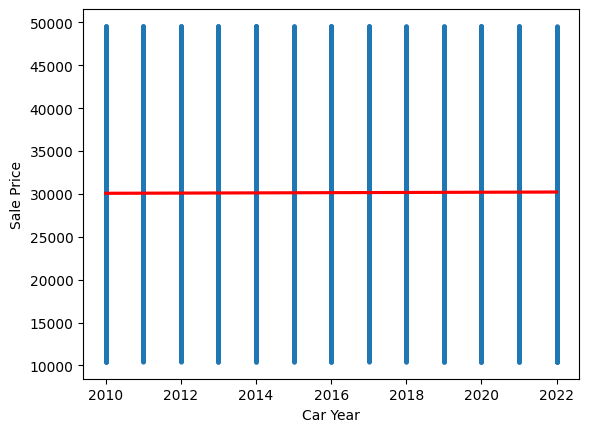

In [ ]:
sns.regplot(
    x='Car Year',
    y='Sale Price',
    data=df.sample(50000, random_state=1),  #50 mil puntos bastan
    scatter_kws={'alpha':0.4, 's':5},
    line_kws={'color':'red'}
)


**Interpretacion estadistica:** El coeficiente negativo (-2.77) indica una muy ligera tendencia decreciente del precio con el año, es decir, los autos mas nuevos **no** se venden más caros, pero esta diferencia es practicamente insignificante.

El coeficiente de determinacion $R^2=0.000$ confirma que el año de fabricacion no explica el precio de venta en el conjunto de datos, el modelo no encuentra relación lineal.

El grafico tambien apoya esta idea, los puntos estan agrupados verticalmente por año, y la linea roja de regresion es practicamente plana, indicando ausencia de tendencia.


**Conclusión**
El modelo de regresión linealentre el año del auto y precio de venta no muestra una relación significativa. El valor de $R^2$(coeficiente de determinacion) y el p-valor(valor de probabilidad) indican que el año de fabricacion no influye significativamente en el precio promedio de venta de los vehículos. A pesar de lo que han indicado graficos anteriores que parecian indicar que los autos antiguos poseian precios superiores a los nuevos, realmente la diferencia establecida no es suficientemente significativa.

Por tanto, la hipotesis planteada no se cumple. Sin embargo, aun cuando la hipotesis no se cumple, este resultado es valioso porque evidencia que el año de fabricacion por sí solo no es un predictor fiable del precio de venta. Es probable que otras variables sean factores determinantes que expliquen la variacion observada en los precios.
